In [1]:
import matplotlib.pyplot as plt
from csv import reader
from math import sqrt
from math import log
from random import sample

selection: list = []
selection_len: int = 0

with open('var_8_loglaplace.csv', mode ='r')as file:
    csvFile = reader(file)
    for lines in csvFile:
        selection.append(float(lines[0]))
        selection_len += 1

Сумма элементов выборки:

In [2]:
def my_sum(array: list) -> float:
    summa: int = 0
    for elem in selection:
        summa += elem
    return round(summa, 2)

In [3]:
my_sum(selection)

-667.93

Выборочное среднее:

In [4]:
def mid(selection: list) -> float:
    summa: int = my_sum(selection)
    return round(summa / selection_len, 2)

In [5]:
mid(selection)

-2.23

Медиана:

In [6]:
def median(selection: list) -> float:
    sorted_selection: list = sorted(selection)
    if selection_len % 2 == 0:
        half: int = int(selection_len / 2)
        return round((sorted_selection[half] + sorted_selection[half + 1]) / 2, 2)
    else:
        return round(sorted_selection[half], 2)

In [7]:
median(selection)

-2.27

Мода:

In [8]:
def moda(selection: list) -> float:
    freq_dict = {}
    for elem in selection:
        freq_dict[elem] = freq_dict.get(elem, 0) + 1
        
    max_freq: int = max(freq_dict.values())

    if(max_freq == 1):
        return None
    
    for key, value in freq_dict.items():
        if value == max_freq:
            return key

In [9]:
print(moda(selection))

None


Размах выборки:

In [10]:
def razmah(selection: list) -> float:
    return round(max(selection) - min(selection), 2)

In [11]:
razmah(selection)

2.24

Смещенная дисперсия:

In [12]:
def smesh_dispersion(selection: list) -> float:
    mid_val: float = mid(selection)
    summa: float = 0
    for elem in selection:
        summa += (mid_val - elem) ** 2
    return round(summa / selection_len, 2)

In [13]:
smesh_dispersion(selection)

0.11

Несмещенная дисперсия:

In [14]:
def nesmesh_dispersion(selection: list) -> float:
    mid_val: float = mid(selection)
    summa: float = 0
    for elem in selection:
        summa += (mid_val - elem) ** 2
    return round(summa / (selection_len - 1), 2)

In [15]:
nesmesh_dispersion(selection)

0.11

Выборочный начальный элемент:

In [16]:
def choose_first_elem(selection: list, k: int) -> float:
    summa: float = 0
    for elem in selection:
        summa += elem ** k
    return round(summa / selection_len, 2)

In [17]:
choose_first_elem(selection, 3)

-11.75

Выборочный центральный элемент:

In [18]:
def choose_center_elem(selection: list, k: int) -> float:
    mid_val: float = mid(selection)
    summa: float = 0
    for elem in selection:
        summa += (mid_val - elem) ** k
    return round(sqrt(summa / selection_len), 2)

In [19]:
choose_center_elem(selection, 6)

0.31

Эмперическая функция распределения:

In [20]:
def ecdf(selection: list, count: int):
    sorted_selection = sorted(selection)

    x = []
    y = []

    for i in range(count):
        x.append(sorted_selection[i])
        y.append((i + 1) / count)

    return x, y

График эмперической функции:

In [21]:
def show_graphic_ecdf(x: list, y: list, count: int = -1):
    plt.figure()
    plt.step(x, y, where='post', label="Эмперическая функция")
    plt.scatter(x, y, label="Точки выборки")
    
    plt.xlabel('x')
    plt.ylabel('F*(x)')
    if(count == -1):
        plt.title(f'Эмперическая функция распределения')
    else:
        plt.title(f'Эмперическая функция распределения для выборки из {count} элементов')
    plt.legend()
    plt.grid()
    
    plt.show()

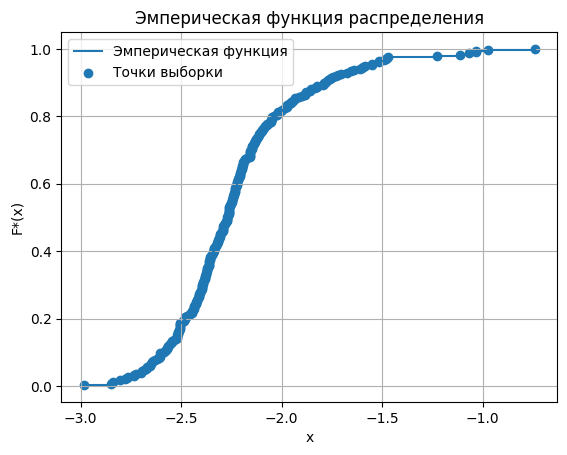

In [22]:
x, y = ecdf(selection, selection_len)
show_graphic_ecdf(x, y)

График эмперичиской функции для 10 случайных элементов:

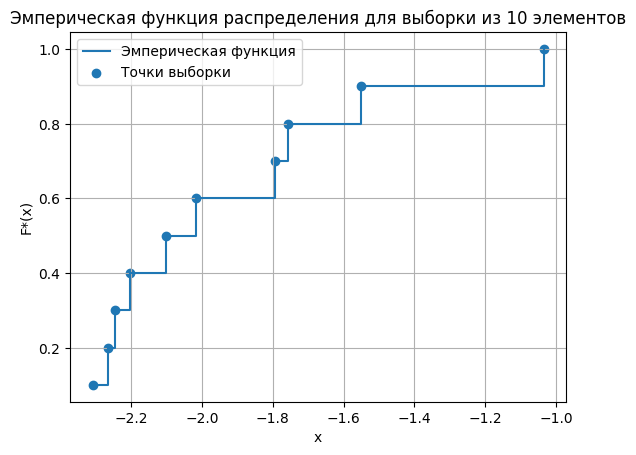

In [23]:
selection_10 = sample(selection, 10)
x, y = ecdf(selection_10, 10)
show_graphic_ecdf(x, y, 10)

График эмперической функции для 100 случайных элементов:

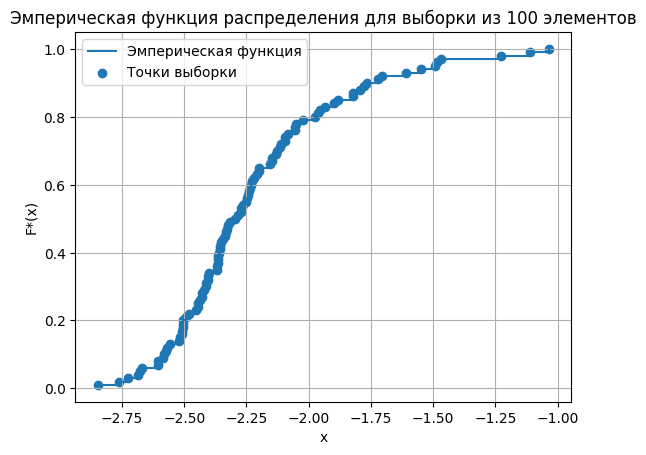

In [24]:
selection_100 = sample(selection, 100)
x, y = ecdf(selection_100, 100)
show_graphic_ecdf(x, y, 100)

График эмперичиской функции для 200 случайных элементов:

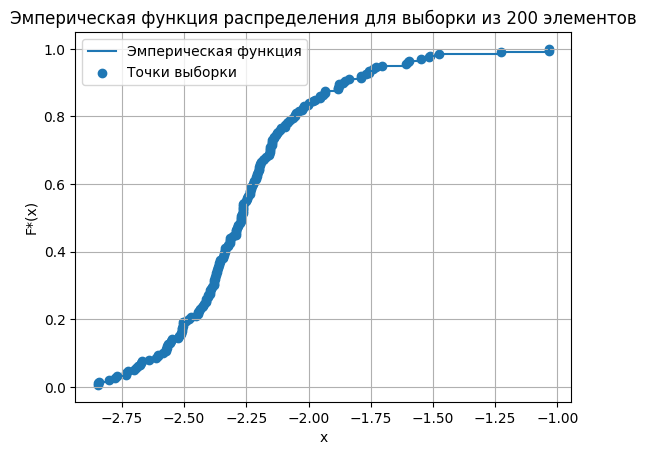

In [25]:
selection_200 = sample(selection, 200)
x, y = ecdf(selection_200, 200)
show_graphic_ecdf(x, y, 200)

In [26]:
def histogram(selection: list, bins= 10):
    min_val = min(selection)
    max_val = max(selection)

    bin_width: float = (max_val - min_val) / bins

    edges = [min_val + i * bin_width for i in range(bins + 1)]

    counts = [0] * bins

    for elem in selection:
        for i in range(bins):
            if(edges[i] <= elem < edges[i+1]):
                counts[i] += 1
                break
        else:
            counts[-1] += 1

    return edges, counts

Гистограмма:

In [27]:
def show_histogram(edges: list, counts: list, vyborka: int = -1):
    centers = [(edges[i] + edges[i+1]) / 2 for i in range(len(edges)-1)]
    
    plt.figure()
    
    plt.bar(centers, counts, width=(edges[1] - edges[0]), alpha=0.6, label="Гистограмма")
    
    plt.plot(centers, counts, marker='o', label="График частот")

    if(vyborka == -1):
        plt.title("Гистограмма")
    else:
        plt.title(f"Гистограмма для выборки из {vyborka} элементов")
    
    plt.xlabel("Значения")
    plt.ylabel("Частота")
    plt.legend()
    plt.grid()
    
    plt.show()

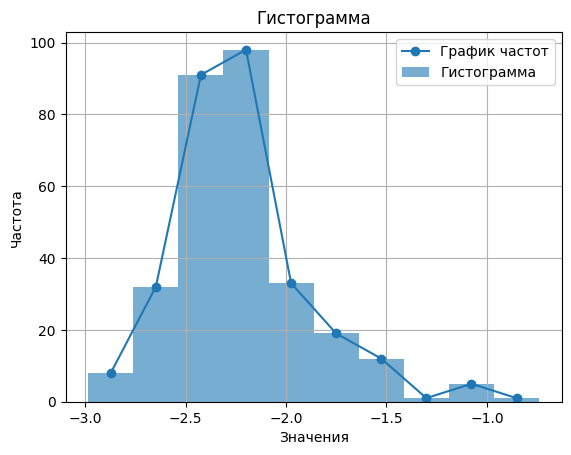

In [28]:
edges, counts = histogram(selection)
show_histogram(edges, counts)

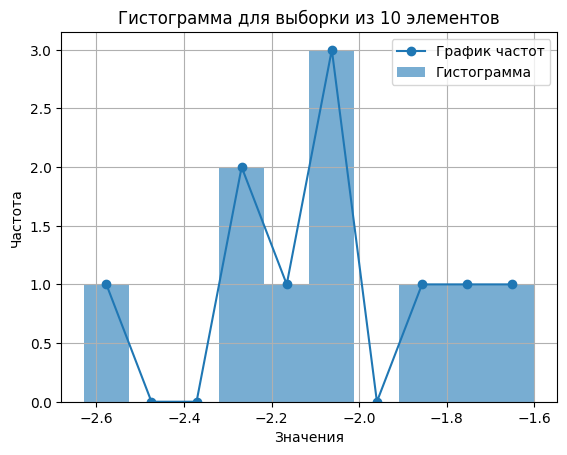

In [29]:
selection_10 = sample(selection, 10)
edges, counts = histogram(selection_10, 10)
show_histogram(edges, counts, 10)

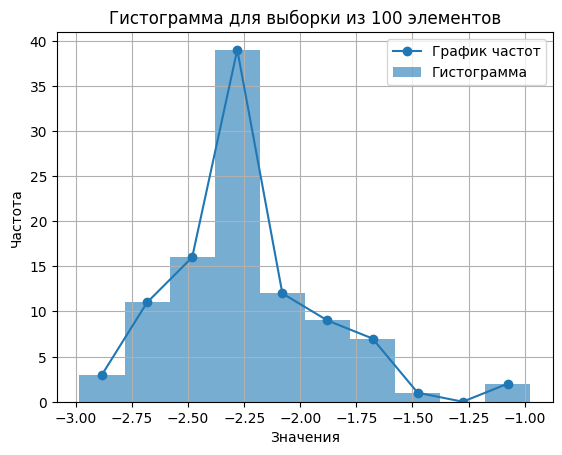

In [30]:
selection_100 = sample(selection, 100)
edges, counts = histogram(selection_100)
show_histogram(edges, counts, 100)

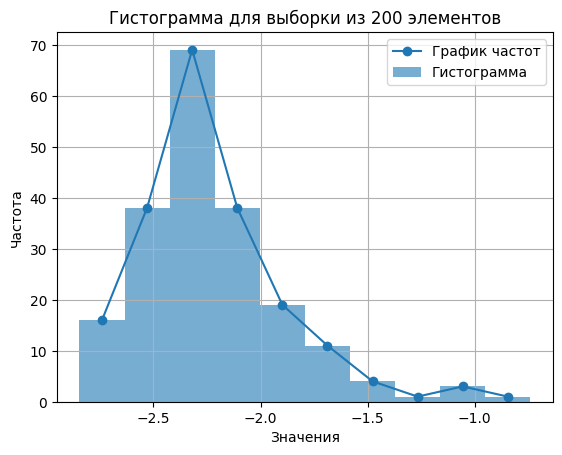

In [31]:
selection_200 = sample(selection, 200)
edges, counts = histogram(selection_200)
show_histogram(edges, counts, 200)

Параметры loc и a по методу моментов:

In [32]:
def find_loc_a_moment(selection: list) -> [float, float]:
    mid_val: float = mid(selection)
    loc: float = median(selection) - 1
    a: float = round((1 + sqrt(1 + 4*(mid_val - loc)**2)) / (2 * (mid_val - loc)), 2)
    
    return a, loc

In [33]:
find_loc_a_moment(selection)

(1.59, -3.27)

Параметры loc и a по методу максимального правдоподобия:

In [34]:
class Point:
    def __init__(self, a: float = 0, loc: float = 0):
        self.a = a
        self.loc = loc

    def get_dist(self, other):
        return sqrt((self.a - other.a) ** 2 + (self.loc - other.loc) ** 2)

    a: float
    loc: float


def find_mid(a: Point, b: Point) -> Point:
    return Point((a.a + b.a) / 2, (a.loc + b.loc) / 2)


def find_new(a: Point, b: Point, c: Point) -> Point:
    mid_point: Point = find_mid(a, b)
    return Point(2 * mid_point.a - c.a, 2 * mid_point.loc - c.loc)


def func_pravdopodobie(selection: list, p: Point) -> float:
    sum_val: float = 0
    for elem in selection:
        fxi: float = 0
        if elem - p.loc <= 1:
            fxi = log(p.a / 2) + (p.a - 1) * log(elem - p.loc)
        else:
            fxi = log(p.a / 2) - (p.a + 1) * log(elem - p.loc)

        sum_val += fxi

    return sum_val


def find_loc_a_max_prav(selection: list) -> list:
    a, loc = find_loc_a_moment(selection)
    point_1 = Point(a, loc + 0.1)
    point_2 = Point(a, loc)
    point_3 = Point(a + 1, loc)

    for _ in range(100000):
        fp1 = func_pravdopodobie(selection, point_1)
        fp2 = func_pravdopodobie(selection, point_2)
        fp3 = func_pravdopodobie(selection, point_3)

        # Условие остановки
        if (point_1.get_dist(point_2) < 0.00001
            and point_2.get_dist(point_3) < 0.00001
            and point_1.get_dist(point_3) < 0.00001):
            break

        # Находим худшую точку
        min_fp = min(fp1, fp2, fp3)

        if min_fp == fp1:
            worst, p2, p3, fw, f2, f3 = point_1, point_2, point_3, fp1, fp2, fp3
        elif min_fp == fp2:
            worst, p2, p3, fw, f2, f3 = point_2, point_1, point_3, fp2, fp1, fp3
        else:
            worst, p2, p3, fw, f2, f3 = point_3, point_1, point_2, fp3, fp1, fp2

        # Отражаем худшую через середину противоположного ребра
        new_point = find_new(p2, p3, worst)
        fp_new = func_pravdopodobie(selection, new_point)

        if fp_new > fw:
            # Отражение улучшило — заменяем худшую
            if min_fp == fp1:
                point_1 = new_point
            elif min_fp == fp2:
                point_2 = new_point
            else:
                point_3 = new_point
        else:
            # Отражение не помогло — сжимаем к лучшей
            max_fp = max(fp1, fp2, fp3)
            if max_fp == fp1:
                best = point_1
            elif max_fp == fp2:
                best = point_2
            else:
                best = point_3

            point_1 = find_mid(best, point_1)
            point_2 = find_mid(best, point_2)
            point_3 = find_mid(best, point_3)

    fp1 = func_pravdopodobie(selection, point_1)
    fp2 = func_pravdopodobie(selection, point_2)
    fp3 = func_pravdopodobie(selection, point_3)
    max_fp = max(fp1, fp2, fp3)
    if max_fp == fp1:
        return [round(point_1.a, 2), round(point_1.loc, 2)]
    elif max_fp == fp2:
        return [round(point_2.a, 2), round(point_2.loc, 2)]
    else:
        return [round(point_3.a, 2), round(point_3.loc, 2)]


In [35]:
find_loc_a_max_prav(selection)

[4.33, -3.27]

График теоретической функции распределения:

In [36]:
def teoretic(selection: list, loc: float, a: float) -> list:
    x = []
    y = []

    sorted_selection = sorted(selection)
    
    for elem in sorted_selection:
        x.append(elem)
        if(loc < elem <= loc + 1):
            y.append(0.5 * (elem - loc)**a)
        elif(elem > loc + 1):
            y.append(1 - 0.5 * (elem - loc)**(-a))

    return x, y

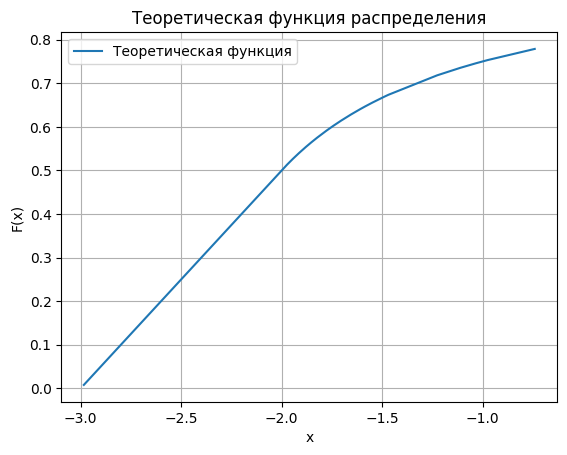

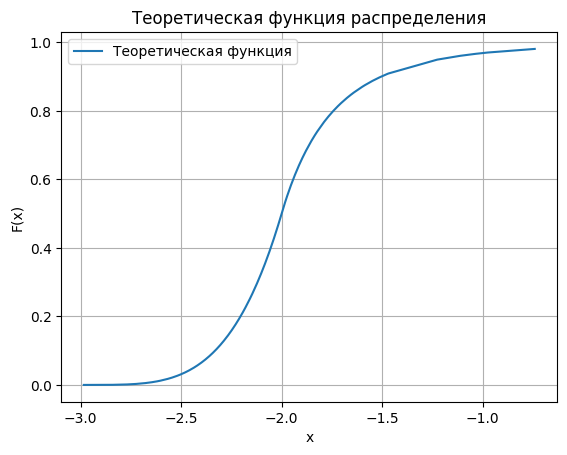

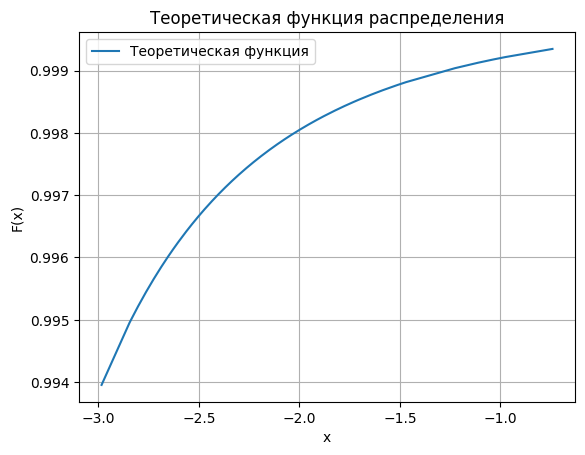

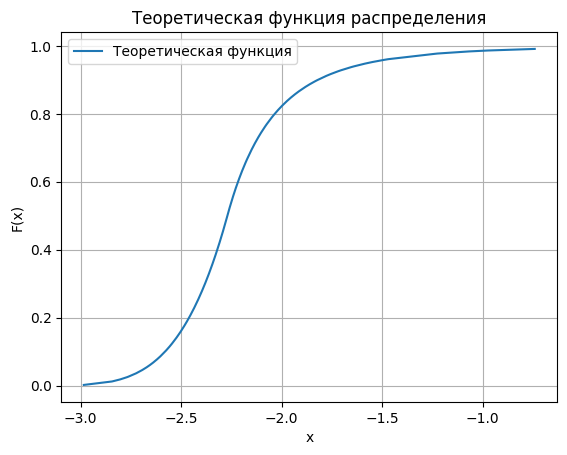

In [37]:
a, loc = find_loc_a_max_prav(selection)
x, y = teoretic(selection, -3, 1)
plt.figure()
plt.plot(x, y, label="Теоретическая функция")

plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Теоретическая функция распределения')
plt.legend()
plt.grid()

plt.show()

a, loc = find_loc_a_max_prav(selection)
x, y = teoretic(selection, -3, 4)
plt.figure()
plt.plot(x, y, label="Теоретическая функция")

plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Теоретическая функция распределения')
plt.legend()
plt.grid()

plt.show()

a, loc = find_loc_a_max_prav(selection)
x, y = teoretic(selection, -6, 4)
plt.figure()
plt.plot(x, y, label="Теоретическая функция")

plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Теоретическая функция распределения')
plt.legend()
plt.grid()

plt.show()

a, loc = find_loc_a_max_prav(selection)
x, y = teoretic(selection, loc, a)
plt.figure()
plt.plot(x, y, label="Теоретическая функция")

plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Теоретическая функция распределения')
plt.legend()
plt.grid()

plt.show()

Мера разброса оценки:

In [38]:
def se_a(a: float, n: float):
    return 1 / sqrt(n / a**2)

def se_loc(selection: list, loc: float, a: float):
    sum_min: float = 0
    sum_max: float = 0
    
    for elem in selection:
        if(elem - loc <= 1):
            sum_min += (1 - a) / (elem - loc)**2
        else:
            sum_max -= (a + 1) / (elem - loc)**2
    
    return 1 / sqrt(-(sum_min + sum_max))

def mera_spread(selection: list, a: float, loc: float, n: float, z: float) -> list:
    return [[round(a - z * se_a(a, n), 2), round(a + z * se_a(a, n), 2)], [round(loc - z * se_loc(selection, loc, a), 2), round(loc + z * se_loc(selection, loc, a), 2)]]

In [39]:
a, loc = find_loc_a_max_prav(selection)

z: float = 1.96
print(mera_spread(selection, a, loc, selection_len, z))
z: float = 2.576
print(mera_spread(selection, a, loc, selection_len, z))

[[3.84, 4.82], [-3.32, -3.22]]
[[3.69, 4.97], [-3.34, -3.2]]
